# Paper figures v2 — comprehensive heatmaps + split-panel Fig 1

Reads the 2026-05-01 result CSVs and produces three figures in the test.pdf style:

- **Fig 1b** (Exp A): two-panel line plot (Green-Level + Median-Filter side by side)
- **Fig 5** (Exp B2): 3×3 grid — best method per (resolution, noise, outlier) cell, all 320 cells visible
- **Fig 6** (Exp B2): 3×3 grid — 3C-FBI Jaccard categorised into 7 performance buckets

Output goes to `CCC_FBI_results/` (dated names) and is **also** copied into the paper `Figures/` folder.
Tweak the cells below directly to re-render — no need to re-run `main_3C_FBI.py`.

In [1]:
# Configuration — edit DATE, paths, palette, layout here
import os, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

DATE        = '20260501'
RESULTS_DIR = '/Users/erc/Documents/3C-FBI-Circle-fitting/CCC_FBI_results'
PAPER_DIR   = '/Users/erc/Documents/nordlinglab-grants-publications-2024/Figures'

METHODS = ['CIBICA', '3C-FBI', 'RHT', 'RCD', 'RFCA', 'Nurunnabi', 'Guo', 'Greco', 'Qi']

# Colors match main_3C_FBI.py (kept consistent across all paper figures)
COLORS = {
    'CIBICA':    '#2ca02c',   # green
    '3C-FBI':    '#1f77b4',   # blue (proposed)
    'RHT':       '#d62728',   # red
    'RCD':       '#ff7f0e',   # orange
    'RFCA':      '#9467bd',   # purple
    'Nurunnabi': '#8c564b',   # brown
    'Guo':       '#e377c2',   # pink
    'Greco':     '#7f7f7f',   # grey
    'Qi':        '#bcbd22',   # olive
}
MARKERS = {'CIBICA':'s','3C-FBI':'o','RHT':'^','RCD':'v','RFCA':'D','Nurunnabi':'P','Guo':'X','Greco':'h','Qi':'*'}

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'figure.dpi':        120,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'lines.linewidth':   2.0,
    'lines.markersize':  6,
})

os.makedirs(RESULTS_DIR, exist_ok=True)
print('Config loaded. Methods:', METHODS)

Config loaded. Methods: ['CIBICA', '3C-FBI', 'RHT', 'RCD', 'RFCA', 'Nurunnabi', 'Guo', 'Greco', 'Qi']


## Helpers

In [ ]:
# Resolution mapping for Exp B2 (Q -> human-readable resolution)
Q_TO_RES = {0:'infinity', 1:'480 x 480', 2:'240 x 240', 3:'160 x 160',
            4:'120 x 120', 6:'80 x 80', 12:'40 x 40', 24:'20 x 20', 40:'12 x 12'}
Q_ORDER  = [0, 1, 2, 3, 4, 6, 12, 24, 40]
NOISE_PCT   = [0, 1, 2, 5, 10]
OUTLIER_PCT = [0, 10, 20, 30, 40, 50, 60, 70]

# Performance categories for Fig 6 (3C-FBI heatmap)
PERF_BINS = [0.0, 0.50, 0.70, 0.80, 0.90, 0.95, 0.99, 1.0001]
PERF_LABELS = ['Very Poor (<0.50)', 'Poor (\u22650.50)', 'Marginal (\u22650.70)',
               'Acceptable (\u22650.80)', 'Good (\u22650.90)',
               'Very Good (\u22650.95)', 'Excellent (\u22650.99)']
PERF_COLORS = ['#000000',    # very poor - black
               '#d73027',    # poor - dark red
               '#f46d43',    # marginal - orange-red
               '#fdae61',    # acceptable - orange
               '#fee08b',    # good - pale yellow
               '#a6d96a',    # very good - light green
               '#1a9850']    # excellent - dark green
PERF_CMAP = ListedColormap(PERF_COLORS)

def jaccard_to_category(j: float) -> int:
    """Map a Jaccard value to its category index 0..6."""
    for i in range(len(PERF_BINS) - 1):
        if PERF_BINS[i] <= j < PERF_BINS[i+1]:
            return i
    return len(PERF_BINS) - 2

print('Helpers loaded. Q_ORDER:', Q_ORDER)


## Figure 1b — Exp A: GL + Med side-by-side line plots

Reads each `A_Jaccard_<METHOD>_<DATE>.csv` (rows = 144 frames, cols = 18 configs), takes mean across frames, and plots GL70..86 on the left subplot and Med3..19 on the right.

GL configs: ['GL70', 'GL72', 'GL74', 'GL76', 'GL78', 'GL80', 'GL82', 'GL84', 'GL86']
Med configs: ['Med3', 'Med5', 'Med7', 'Med9', 'Med11', 'Med13', 'Med15', 'Med17', 'Med19']


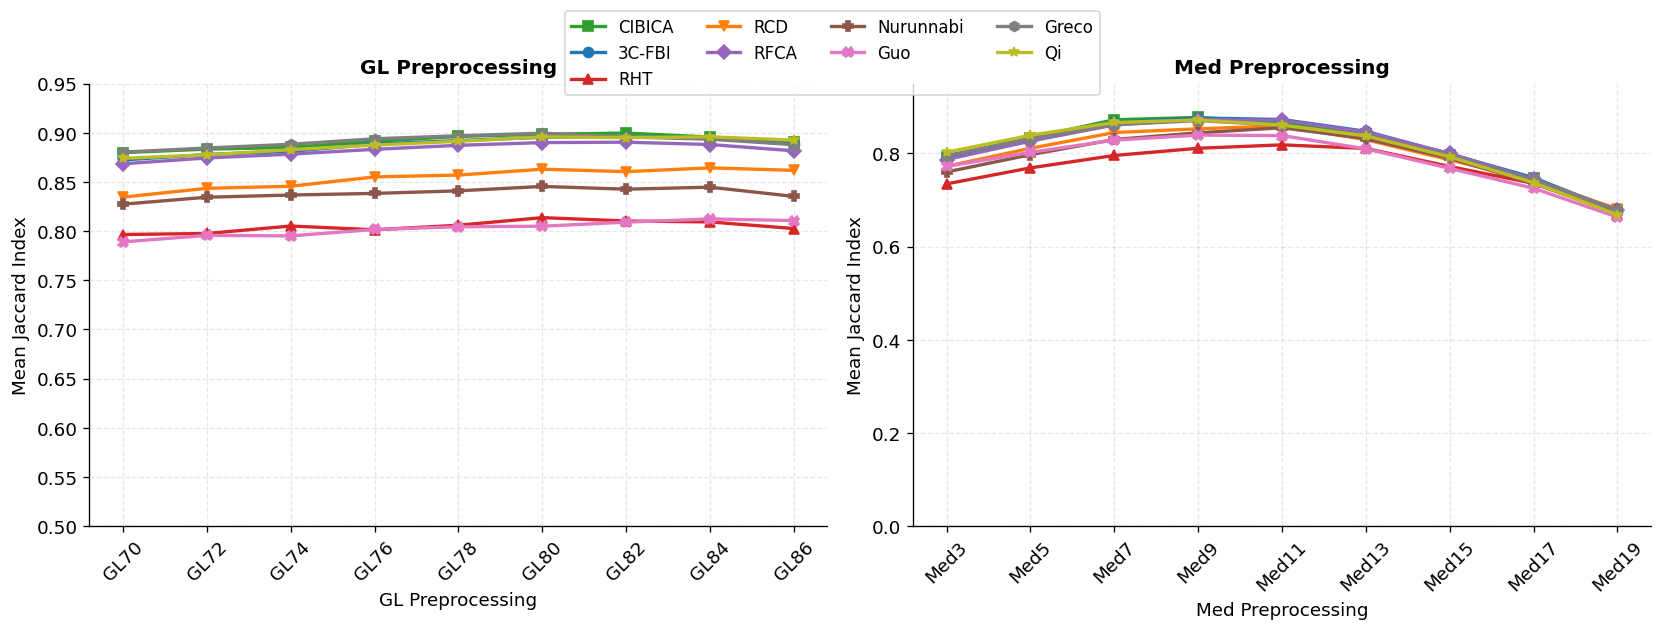

Saved: /Users/erc/Documents/3C-FBI-Circle-fitting/CCC_FBI_results/A_Fig1b_Jaccard_GL_Med_TwoPanel_20260501.png, /Users/erc/Documents/3C-FBI-Circle-fitting/CCC_FBI_results/A_Fig1b_Jaccard_GL_Med_TwoPanel_20260501.pdf


In [3]:
# Build per-method mean Jaccard for each config
all_methods_mean = {}
for m in METHODS:
    p = os.path.join(RESULTS_DIR, f'A_Jaccard_{m}_{DATE}.csv')
    if not os.path.exists(p):
        print(f'Warning: missing {p}'); continue
    df = pd.read_csv(p, index_col='Filename')
    all_methods_mean[m] = df.mean(axis=0)

GL_COLS  = [c for c in all_methods_mean[METHODS[0]].index if c.startswith('GL')]
MED_COLS = [c for c in all_methods_mean[METHODS[0]].index if c.startswith('Med')]
print(f'GL configs: {GL_COLS}')
print(f'Med configs: {MED_COLS}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for m in METHODS:
    if m not in all_methods_mean: continue
    s = all_methods_mean[m]
    axes[0].plot(GL_COLS, s[GL_COLS].values, label=m, color=COLORS[m],
                 marker=MARKERS[m], linewidth=2.0, markersize=6)
    axes[1].plot(MED_COLS, s[MED_COLS].values, label=m, color=COLORS[m],
                 marker=MARKERS[m], linewidth=2.0, markersize=6)

axes[0].set_title('GL Preprocessing')
axes[0].set_xlabel('GL Preprocessing'); axes[0].set_ylabel('Mean Jaccard Index')
axes[0].set_ylim(0.50, 0.95); axes[0].tick_params(axis='x', rotation=45)

axes[1].set_title('Med Preprocessing')
axes[1].set_xlabel('Med Preprocessing'); axes[1].set_ylabel('Mean Jaccard Index')
axes[1].set_ylim(0.00, 0.95); axes[1].tick_params(axis='x', rotation=45)

# Shared legend at the top, no title
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.06),
           ncol=4, frameon=True, fontsize=10)
plt.tight_layout()
out = os.path.join(RESULTS_DIR, f'A_Fig1b_Jaccard_GL_Med_TwoPanel_{DATE}')
plt.savefig(out + '.png'); plt.savefig(out + '.pdf')
plt.show()
print(f'Saved: {out}.png, {out}.pdf')

## Figure 5 — Best method per (resolution, noise, outlier): 3×3 grid

8 panels = 8 resolutions; 9th panel = method legend. Each cell is colored by the winning method (one color per method) and labeled with its mean Jaccard.

In [ ]:
df = pd.read_csv(os.path.join(RESULTS_DIR, f'B2_Jaccard_Full_{DATE}.csv'))
print('B2 rows:', len(df), '- methods:', df['Method'].unique())

# Build (Q, noise, outlier) -> winning method matrix and the corresponding Jaccard
best_method = {}   # {q: 2D str array shape (5 noise, 8 outlier)}
best_jacc   = {}   # same shape, float
method_cmap = ListedColormap([COLORS[m] for m in METHODS])

for q in Q_ORDER:
    M = np.empty((len(NOISE_PCT), len(OUTLIER_PCT)), dtype=object)
    J = np.zeros_like(M, dtype=float)
    sub = df[df['Q'] == q]
    for i, n in enumerate(NOISE_PCT):
        for k, o in enumerate(OUTLIER_PCT):
            cell = sub[(sub['Noise_pct'] == n) & (sub['Outlier_pct'] == o)]
            cell = cell.set_index('Method').reindex(METHODS).reset_index()
            best_idx = cell['Jaccard_Mean'].idxmax()
            M[i, k] = cell.loc[best_idx, 'Method']
            J[i, k] = cell.loc[best_idx, 'Jaccard_Mean']
    best_method[q] = M
    best_jacc[q]   = J

method_to_idx = {m: i for i, m in enumerate(METHODS)}

# Layout: 3x3 with all 9 resolution panels (legend goes above the figure)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax_idx, q in enumerate(Q_ORDER):
    ax = axes.flat[ax_idx]
    M, J = best_method[q], best_jacc[q]
    M_idx = np.vectorize(method_to_idx.get)(M)
    ax.imshow(M_idx, aspect='auto', cmap=method_cmap, vmin=-0.5, vmax=len(METHODS)-0.5)
    ax.set_xticks(range(len(OUTLIER_PCT))); ax.set_xticklabels(OUTLIER_PCT)
    ax.set_yticks(range(len(NOISE_PCT)));   ax.set_yticklabels(NOISE_PCT)
    ax.set_title(f'Resolution: {Q_TO_RES[q]}')
    ax.set_xlabel('Percentage of Outliers')
    ax.set_ylabel('Radial Noise (\u03c3)')
    ax.grid(False)
    for i in range(len(NOISE_PCT)):
        for k in range(len(OUTLIER_PCT)):
            txt_color = 'white' if M[i, k] in ('CIBICA','3C-FBI','RHT','RFCA','Nurunnabi','Greco') else 'black'
            ax.text(k, i, f'{J[i, k]:.3f}', ha='center', va='center', fontsize=7,
                    color=txt_color, fontweight='bold')

# Hide any unused cells (in case Q_ORDER < 9)
for ax_idx in range(len(Q_ORDER), 9):
    axes.flat[ax_idx].axis('off')

# Method legend at the top of the figure, single row
patches = [Patch(facecolor=COLORS[m], edgecolor='black', label=m) for m in METHODS]
fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(METHODS), fontsize=10, frameon=True, title=None)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # leave room at top for legend
out = os.path.join(RESULTS_DIR, f'B2_Fig5_BestMethod_AllRes_{DATE}')
plt.savefig(out + '.png'); plt.savefig(out + '.pdf')
plt.show()
print(f'Saved: {out}.png, {out}.pdf')


## Figure 6 — 3C-FBI performance categorised: 3×3 grid

Same 8-resolution layout. Cells coloured by 7 performance categories; cell text shows the Jaccard value. The 9th panel holds the category legend.

In [ ]:
# 3C-FBI rows only
fbi = df[df['Method'] == '3C-FBI']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax_idx, q in enumerate(Q_ORDER):
    ax = axes.flat[ax_idx]
    cat = np.zeros((len(NOISE_PCT), len(OUTLIER_PCT)), dtype=int)
    val = np.zeros_like(cat, dtype=float)
    for i, n in enumerate(NOISE_PCT):
        for k, o in enumerate(OUTLIER_PCT):
            cell = fbi[(fbi['Q'] == q) & (fbi['Noise_pct'] == n) & (fbi['Outlier_pct'] == o)]
            j = float(cell['Jaccard_Mean'].iloc[0]) if len(cell) else 0.0
            val[i, k] = j
            cat[i, k] = jaccard_to_category(j)
    ax.imshow(cat, aspect='auto', cmap=PERF_CMAP, vmin=0, vmax=len(PERF_LABELS) - 1)
    ax.set_xticks(range(len(OUTLIER_PCT))); ax.set_xticklabels(OUTLIER_PCT)
    ax.set_yticks(range(len(NOISE_PCT)));   ax.set_yticklabels(NOISE_PCT)
    ax.set_title(f'Resolution: {Q_TO_RES[q]}')
    ax.set_xlabel('Percentage of Outliers')
    ax.set_ylabel('Radial Noise (\u03c3)')
    ax.grid(False)
    for i in range(len(NOISE_PCT)):
        for k in range(len(OUTLIER_PCT)):
            tc = 'white' if cat[i, k] <= 2 else 'black'
            ax.text(k, i, f'{val[i, k]:.3f}', ha='center', va='center',
                    fontsize=7, color=tc, fontweight='bold')

for ax_idx in range(len(Q_ORDER), 9):
    axes.flat[ax_idx].axis('off')

# Category legend at top, single row, Excellent first
patches = [Patch(facecolor=PERF_COLORS[i], edgecolor='black', label=PERF_LABELS[i])
           for i in range(len(PERF_LABELS) - 1, -1, -1)]
fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, 1.03),
           ncol=len(PERF_LABELS), fontsize=9, frameon=True,
           title='Performance categories (3C-FBI)', title_fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
out = os.path.join(RESULTS_DIR, f'B2_Fig6_3CFBI_Performance_Categories_{DATE}')
plt.savefig(out + '.png'); plt.savefig(out + '.pdf')
plt.show()
print(f'Saved: {out}.png, {out}.pdf')


## Copy figures into the paper Figures/ folder

Edit `PAPER_DIR` at the top of the notebook to point at your paper repo.

In [6]:
if not os.path.isdir(PAPER_DIR):
    print(f'PAPER_DIR not found: {PAPER_DIR}\nSkipping copy. Edit the path in the config cell and re-run this cell.')
else:
    pairs = [
        (f'A_Fig1b_Jaccard_GL_Med_TwoPanel_{DATE}',           'Roman2024_Jaccard_AllConfigs_TwoPanel'),
        (f'B2_Fig5_BestMethod_AllRes_{DATE}',                  'Roman2024_Jaccard_Heatmap3_BestMethod_AllRes'),
        (f'B2_Fig6_3CFBI_Performance_Categories_{DATE}',       'Roman2024_Jaccard_Heatmap3_3CFBI_Categories'),
    ]
    for src_stem, dst_stem in pairs:
        for ext in ('.png', '.pdf'):
            src = os.path.join(RESULTS_DIR, src_stem + ext)
            dst = os.path.join(PAPER_DIR,   dst_stem  + ext)
            if os.path.exists(src):
                shutil.copy2(src, dst)
                print(f'Copied {os.path.basename(src)} -> {dst}')
            else:
                print(f'Missing source: {src}')
    print('\nDone.')

Copied A_Fig1b_Jaccard_GL_Med_TwoPanel_20260501.png -> /Users/erc/Documents/nordlinglab-grants-publications-2024/Figures/Roman2024_Jaccard_AllConfigs_TwoPanel.png
Copied A_Fig1b_Jaccard_GL_Med_TwoPanel_20260501.pdf -> /Users/erc/Documents/nordlinglab-grants-publications-2024/Figures/Roman2024_Jaccard_AllConfigs_TwoPanel.pdf
Copied B2_Fig5_BestMethod_AllRes_20260501.png -> /Users/erc/Documents/nordlinglab-grants-publications-2024/Figures/Roman2024_Jaccard_Heatmap3_BestMethod_AllRes.png
Copied B2_Fig5_BestMethod_AllRes_20260501.pdf -> /Users/erc/Documents/nordlinglab-grants-publications-2024/Figures/Roman2024_Jaccard_Heatmap3_BestMethod_AllRes.pdf
Copied B2_Fig6_3CFBI_Performance_Categories_20260501.png -> /Users/erc/Documents/nordlinglab-grants-publications-2024/Figures/Roman2024_Jaccard_Heatmap3_3CFBI_Categories.png
Copied B2_Fig6_3CFBI_Performance_Categories_20260501.pdf -> /Users/erc/Documents/nordlinglab-grants-publications-2024/Figures/Roman2024_Jaccard_Heatmap3_3CFBI_Categories.pd